In [ ]:














import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv(r"C:\Users\harsh\OneDrive\Desktop\OptiCrop\data\Crop_recommendation.csv")
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [4]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [5]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

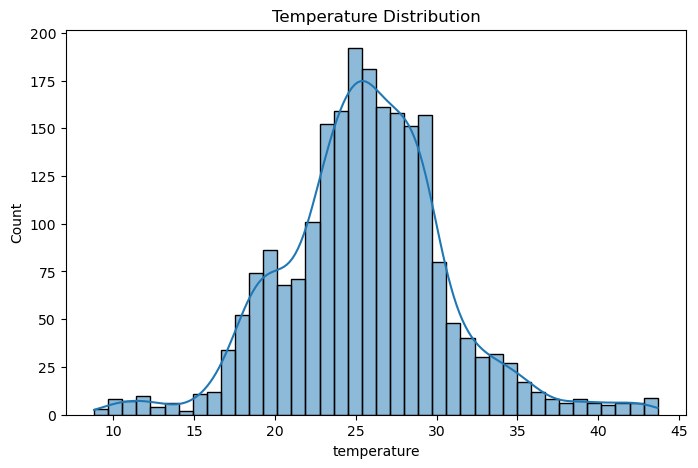

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["temperature"], kde=True)

plt.title("Temperature Distribution")
plt.show()

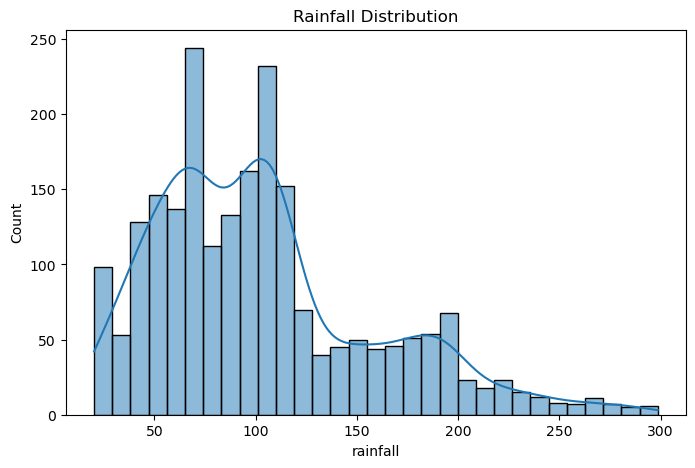

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["rainfall"], kde=True)

plt.title("Rainfall Distribution")
plt.show()


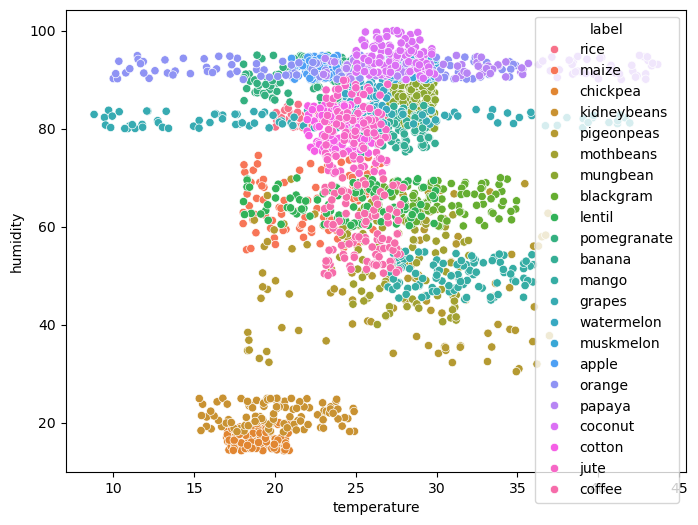

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="temperature",
    y="humidity",
    data=df,
    hue="label"
)

plt.show()

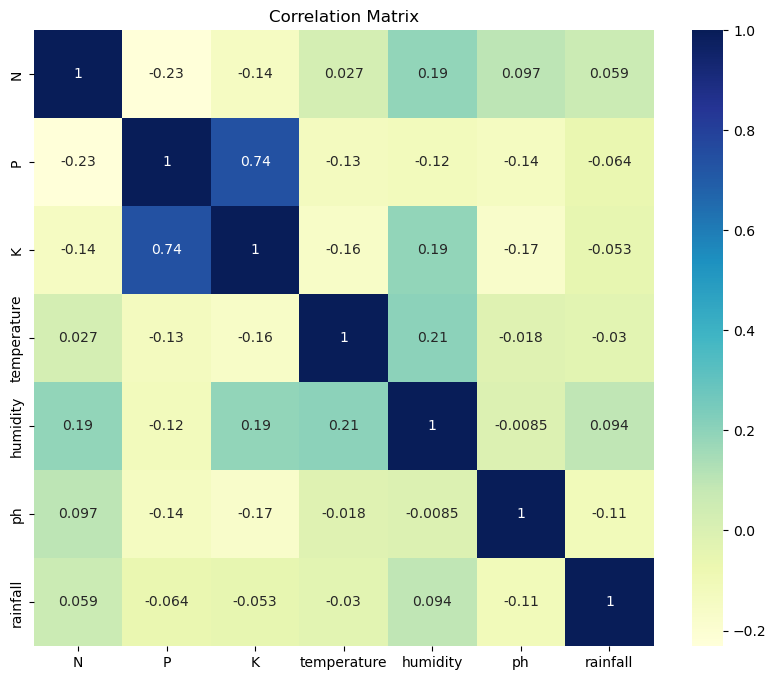

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation Matrix")
plt.show()

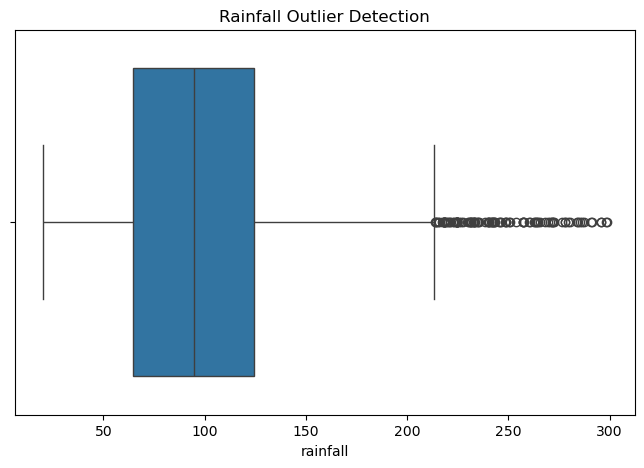

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["rainfall"])

plt.title("Rainfall Outlier Detection")
plt.show()

In [12]:
seasonal_crops = {
    "rice":"Kharif",
    "maize":"Kharif",
    "chickpea":"Rabi",
    "kidneybeans":"Kharif",
    "pigeonpeas":"Kharif",
    "mothbeans":"Kharif",
    "mungbean":"Kharif",
    "blackgram":"Kharif",
    "lentil":"Rabi",
    "cotton":"Kharif",
    "jute":"Kharif"
}

seasonal_crops

{'rice': 'Kharif',
 'maize': 'Kharif',
 'chickpea': 'Rabi',
 'kidneybeans': 'Kharif',
 'pigeonpeas': 'Kharif',
 'mothbeans': 'Kharif',
 'mungbean': 'Kharif',
 'blackgram': 'Kharif',
 'lentil': 'Rabi',
 'cotton': 'Kharif',
 'jute': 'Kharif'}

In [13]:
X = df.drop("label", axis=1)

y = df["label"]

In [14]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1760, 7)
(440, 7)


In [16]:
kmeans = KMeans(
    n_clusters=22,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

print("K-Means Completed")

K-Means Completed


In [17]:
lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.975


C:\Users\harsh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_accuracy = accuracy_score(
    y_test,
    knn.predict(X_test)
)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9704545454545455


In [19]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_accuracy = accuracy_score(
    y_test,
    dt.predict(X_test)
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9863636363636363


In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_accuracy = accuracy_score(
    y_test,
    rf.predict(X_test)
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9931818181818182


In [21]:
results = pd.DataFrame({
    "Model":[
        "KNN",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        knn_accuracy,
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,Random Forest,0.993182
2,Decision Tree,0.986364
1,Logistic Regression,0.975000
0,KNN,0.970455


In [22]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

pickle.dump(
    rf,
    open("../models/crop_model.pkl","wb")
)

pickle.dump(
    encoder,
    open("../models/label_encoder.pkl","wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
sample = [[90,42,43,20.8,82,6.5,202]]

prediction = rf.predict(sample)

crop = encoder.inverse_transform(prediction)

print("Recommended Crop:", crop[0])

Recommended Crop: rice


C:\Users\harsh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
Conclusion

The OptiCrop system successfully analyzed agricultural data and applied machine learning algorithms including KNN, Logistic Regression, Decision Tree, Random Forest, and K-Means Clustering.

Among all models, Random Forest achieved the highest accuracy and was selected as the final prediction model. The trained model was saved and integrated with the Flask application to provide intelligent crop recommendations based on soil nutrients and environmental conditions.